In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn import metrics

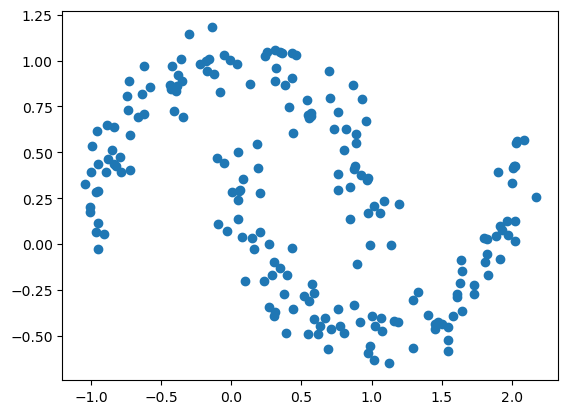

In [3]:
#Generate data
X, y = datasets.make_moons(n_samples=200, noise=0.1)
plt.scatter(X[:,0], X[:,1])
plt.show()

In [4]:
#distance function
def dist(a, b):
    return np.linalg.norm(a-b)
def get_neighbours(X, point, eps):
    neighbours = []
    for i in range(X.shape[0]):
        if dist(X[i], point) < eps:
            neighbours.append(i)
    return neighbours
def dbscan(X, eps, min_pts):
    labels = np.zeros(X.shape[0])
    cluster = 0
    for i in range(X.shape[0]):
        if labels[i] != 0:
            continue
        neighbours = get_neighbours(X, X[i], eps)
        if len(neighbours) < min_pts:
            labels[i] = -1
            continue
        cluster += 1
        labels[i] = cluster
        for j in neighbours:
            if labels[j] == -1:
                labels[j] = cluster
            if labels[j] != 0:
                continue
            labels[j] = cluster
            new_neighbours = get_neighbours(X, X[j], eps)
            if len(new_neighbours) >= min_pts:
                neighbours += new_neighbours
    return labels


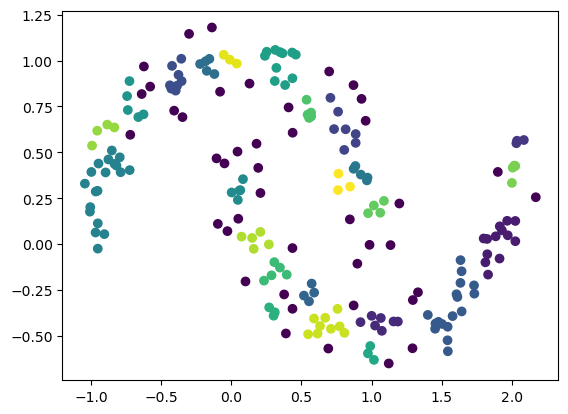

0.2223388600906789


In [5]:
#run dbscan
labels = dbscan(X, 0.1, 3)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()
print(metrics.silhouette_score(X, labels))

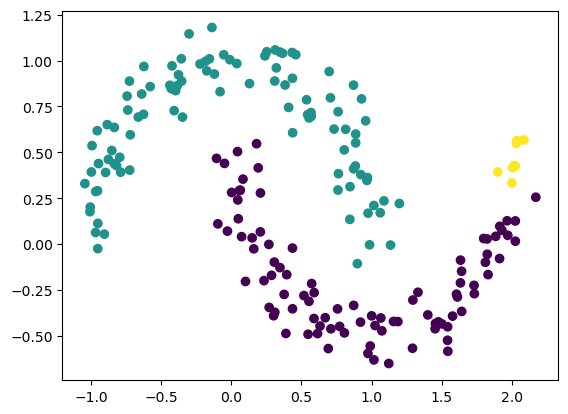

0.22143605379784126


In [6]:
labels = dbscan(X, 0.2, 5)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()
print(metrics.silhouette_score(X, labels))

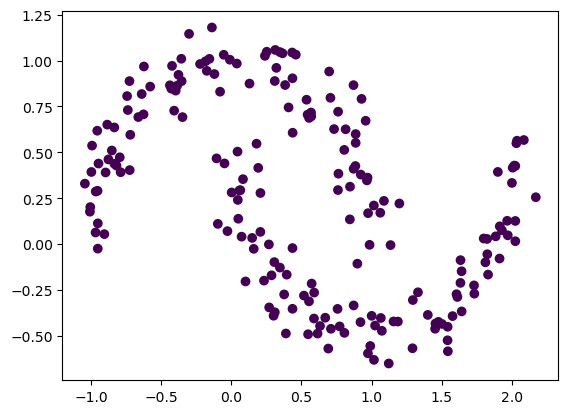

In [7]:
labels = dbscan(X, 0.3, 7)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [8]:
X,y=datasets.make_blobs(n_samples = 200, n_features = 2, centers = 4, random_state = 23)

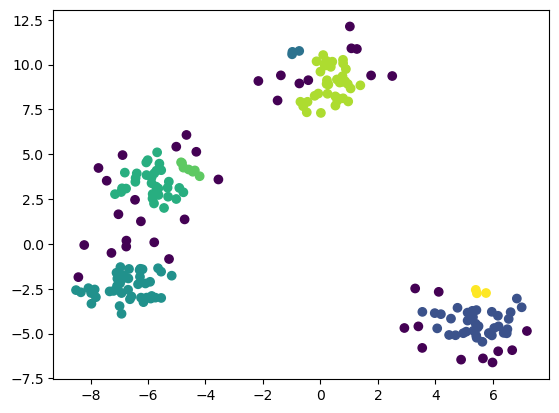

0.22703611608174198


In [9]:
labels = dbscan(X, 0.6, 3)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()
print(metrics.silhouette_score(X, labels))

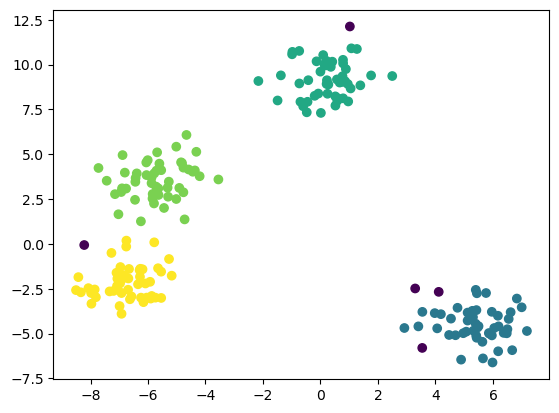

0.7120726977504797


In [10]:
labels = dbscan(X, 1, 3)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()
print(metrics.silhouette_score(X, labels))

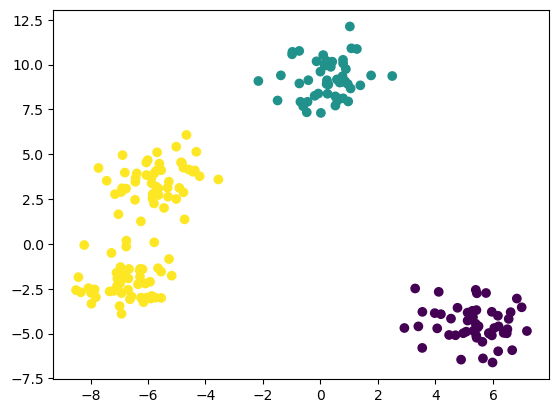

In [11]:
labels = dbscan(X, 2, 3)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()

In [12]:
#cluster evaluation
from sklearn import metrics
print(metrics.silhouette_score(X, labels))


0.7292345593366895


In [13]:
X,y=datasets.load_iris(return_X_y=True)

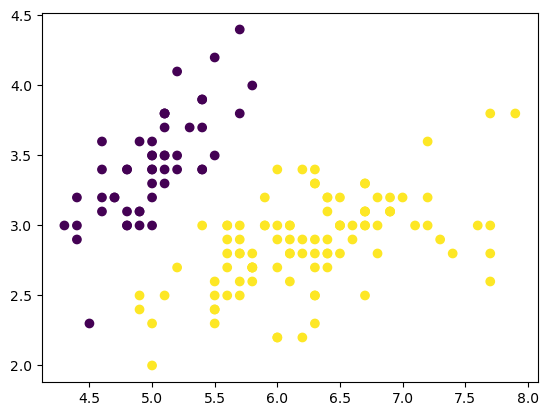

0.6867350732769777


In [14]:
labels = dbscan(X, 0.9, 3)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()
print(metrics.silhouette_score(X, labels))

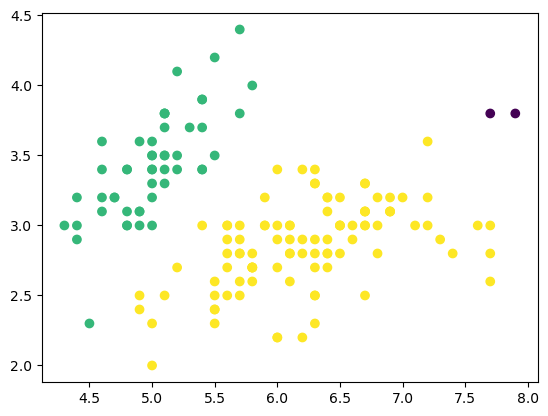

0.5121107753649307


In [16]:
labels = dbscan(X, 0.75, 3)
plt.scatter(X[:,0], X[:,1], c=labels)
plt.show()
print(metrics.silhouette_score(X, labels))